**AI-Based** **Underwater** **Waste** **Detection**
**Final** **Optimised** **YOLOv8**







**Objective**

The purpose of this notebook is to develop and evaluate the final optimised YOLOv8 underwater waste detection model.
This final configuration was selected after analysing multiple controlled experiments involving:
*Image resolution
*   Training duration
*   Model variants
*   Augmentation techniques
The aim is to achieve balanced detection performance while maintaining computational efficiency.

In [ ]:
!pip install ultralytics
from ultralytics import YOLO

In [ ]:
!nvidia-smi

Fri May  8 05:31:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             31W /   70W |    4009MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%%writefile /content/drive/MyDrive/trash_ICRA19/data.yaml
path: /content/drive/MyDrive/trash_ICRA19/dataset
train: train
val: val
test: test

names:
  0: plastic
  1: bio
  2: rov

Overwriting /content/drive/MyDrive/trash_ICRA19/data.yaml


In [ ]:
# Load your best trained model
trained_model = YOLO('/content/runs/detect/train/weights/yolov8s.pt')

# 1. Run detection on a photograph (Photography Input)
photo_results = trained_model.predict(source='/content/drive/MyDrive/trash_ICRA19/dataset/test/images/bio0000_frame0000016.jpg', save=True)

# 2. Run detection on a video (Video Input)
video_results = trained_model.predict(source='/content/drive/MyDrive/trash_ICRA19/dataset/videos_for_testing/manythings.mp4', save=True)


image 1/1 /content/drive/MyDrive/trash_ICRA19/dataset/test/images/bio0000_frame0000016.jpg: 480x640 1 bird, 48.6ms
Speed: 2.9ms preprocess, 48.6ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict-2

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1168) /content/drive/MyDrive/trash_ICRA19/dataset/videos_for_testing/manythings.mp4: 480x640 (no detections), 13.0ms
video 1/1 (frame 2/1168) /content/drive/MyDrive/trash_ICRA19/

**Final Model Configuration**

Selected configuration:
Model: YOLOv8n
Epochs: 50
Image size: 640
Device:0
Augmentation: Enabled

In [ ]:
from ultralytics import YOLO

# 1. Load a pretrained model
model = YOLO('yolov8s.pt')

# 2. Train the model using your data.yaml
results = model.train(
    data='/content/drive/MyDrive/trash_ICRA19/data.yaml',
    epochs=30,      # Number of training rounds
    imgsz=640,     # Image size
    device=0       # Use GPU
)

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/trash_ICRA19/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

Testing and Inference

In [ ]:
# Run detection on an image
results = model.predict(source='/content/drive/MyDrive/trash_ICRA19/dataset/test/images/bio0000_frame0000016.jpg', save=True)

# Run detection on a video
results = model.predict(source='/content/drive/MyDrive/trash_ICRA19/dataset/videos_for_testing/manythings.mp4', save=True)


image 1/1 /content/drive/MyDrive/trash_ICRA19/dataset/test/images/bio0000_frame0000016.jpg: 480x640 2 bios, 14.0ms
Speed: 3.2ms preprocess, 14.0ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict-3

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1168) /content/drive/MyDrive/trash_ICRA19/dataset/videos_for_testing/manythings.mp4: 480x640 (no detections), 7.8ms
video 1/1 (frame 2/1168) /content/drive/MyDrive/trash_ICRA19/d

**Predictions**

For Prediction photos could not be put in due to prediction folder results being deleted.

**Overignal vs Prediction**

For Orignal vs Prediction photos could not be put in due to prediction folder results being deleted but to show what images it was going off the images below show them.

Original image of bio0000_frame0000016.jpg

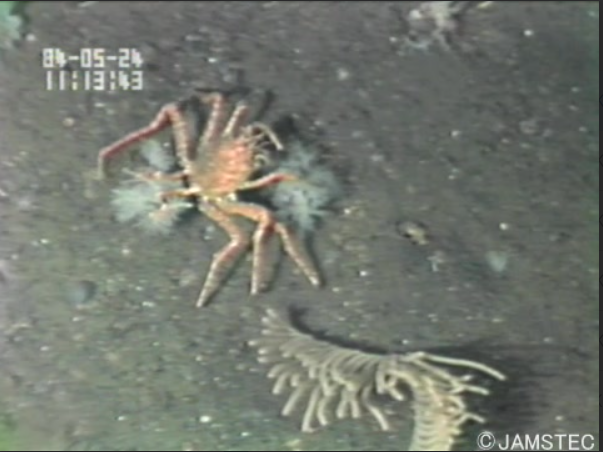

Image taken from the Original manythings.mp4

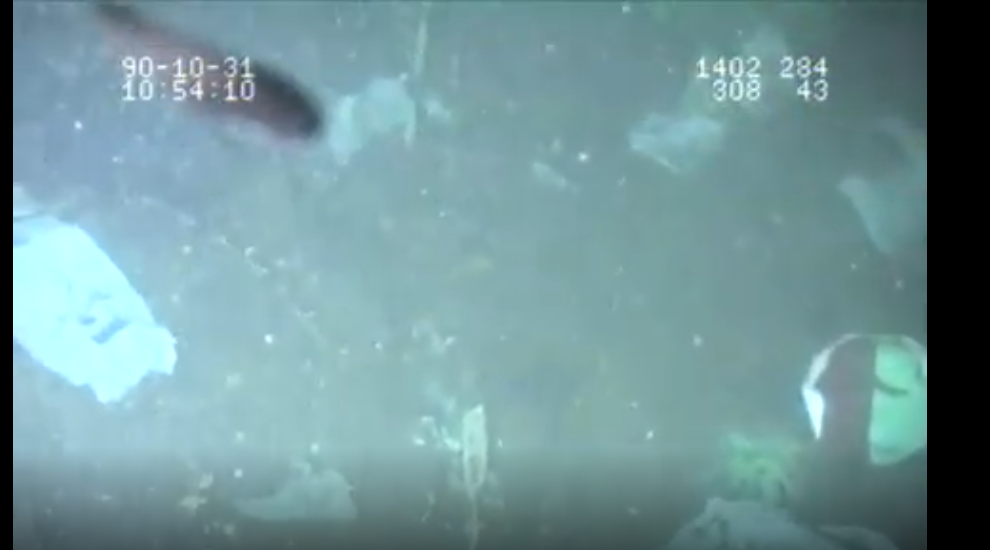

**Confusion Matrix**

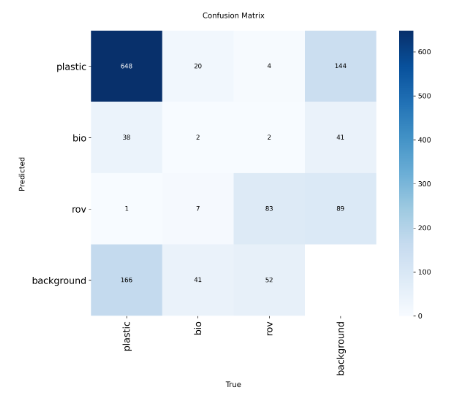

**Failure Analysis**

Despite improvements, several challenges remained during underwater object detection.
Some small or partially obscured objects produced lower confidence scores due to:
*   Underwater blur
*   Low visibility
*   Object overlap
*   Cluttered backgrounds
Certain detections also showed imperfect localisation in difficult underwater conditions.

**Baseline vs Final Model Comparison**

Metric	Baseline	Final Model
Precision 0.494	  0.556
Recall	0.471	    0.483
mAP50	  0.455	    0.500
mAP50-95 0.300	 0.322

Improvement Analysis
Compared with the baseline YOLOv8n model, the final optimised model achieved measurable improvements across multiple evaluation metrics.
The experiments demonstrated that image resolution optimisation and augmentation improved overall underwater waste detection performance while maintaining reasonable computational efficiency.
The final configuration was selected based on balanced performance rather than accuracy alone.

**YOLOv8n vs YOLOv8s Comparison**

The YOLOv8s model achieved slightly higher Precision in some cases due to stronger feature learning capabilities. However, it also required higher computational resources and did not consistently outperform YOLOv8n across all evaluation metrics.
Therefore, YOLOv8n was selected for the final model because it provided a better balance between detection performance, computational efficiency, and practical deployment suitability.

**Accuracy vs Computational Cost**

Experiments showed that increasing image size and training duration increased computational cost significantly.
Although some configurations slightly improved certain metrics, the improvements were not always proportional to the additional training time and GPU usage.
Therefore, the final model was selected based on balanced overall performance rather than maximum accuracy alone.

**Conclusion**

The final optimised YOLOv8n model successfully improved underwater waste detection performance through controlled experimentation and optimisation.
The selected configuration achieved stronger overall performance while maintaining computational efficiency, demonstrating the effectiveness of AI-based object detection for environmental monitoring applications.

Overall this task was completed fully with the code as as it executed the code perfectly with no issues and did what it was meant to. However the results could not be shown due to the folder for results being deleted due to Google Colab time running out howevver before it was deleted the confusion graph was retrieved.